Распределение классов:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


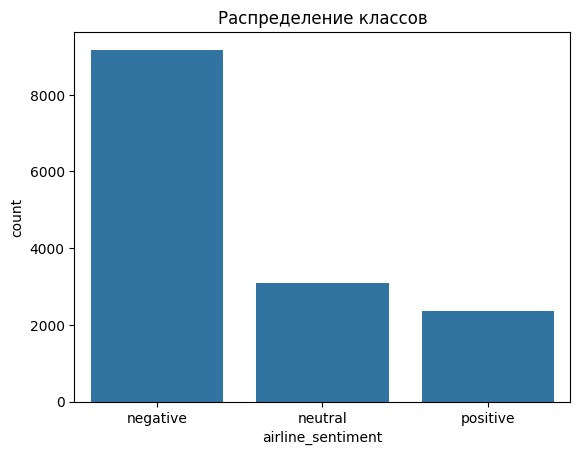


Статистика длины твита:
count    11712.000000
mean       103.924863
std         36.221368
min         12.000000
25%         77.000000
50%        115.000000
75%        136.000000
max        176.000000
Name: tweet_len, dtype: float64

Средняя длина по классам:
airline_sentiment
negative    114.017704
neutral      87.892295
positive     85.741270
Name: tweet_len, dtype: float64

Корреляционная матрица числовых признаков:
           tweet_len  sentiment
tweet_len   1.000000  -0.338248
sentiment  -0.338248   1.000000


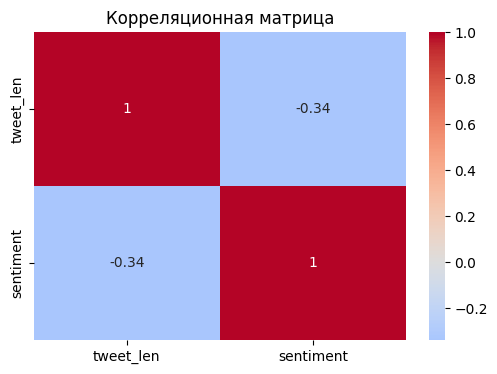

Пропуски до очистки:
text         0
airline      0
tweet_len    0
dtype: int64
text         0
airline      0
tweet_len    0
dtype: int64
Пропуски после очистки:
text         0
airline      0
tweet_len    0
dtype: int64
text         0
airline      0
tweet_len    0
dtype: int64
k=1 -> accuracy=0.6530
k=2 -> accuracy=0.6872
k=3 -> accuracy=0.6954
k=4 -> accuracy=0.6995
k=5 -> accuracy=0.7005
k=6 -> accuracy=0.7049
k=7 -> accuracy=0.7094
k=8 -> accuracy=0.7131
k=9 -> accuracy=0.7114
k=10 -> accuracy=0.7155

Лучшее k = 10, accuracy = 0.7155

Classification report:
              precision    recall  f1-score   support

    negative      0.749     0.930     0.829      1835
     neutral      0.557     0.353     0.432       620
    positive      0.664     0.359     0.466       473

    accuracy                          0.716      2928
   macro avg      0.657     0.547     0.576      2928
weighted avg      0.694     0.716     0.687      2928



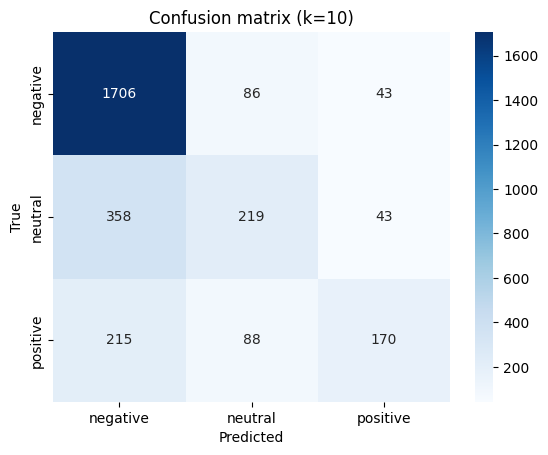


=== Общие выводы ===
1. Лучшее k = 10, accuracy на тесте = 71.5 %.
2. Модель отлично находит negative-класс, но путает neutral и positive.
3. Основные признаки: TF-IDF (3000 слов) + авиакомпания + длина твита.
4. Классы несбалансированы (63 % negative), что сказывается на метриках.



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.sparse import hstack


# ОПИСАНИЕ ЗАДАЧИ
# Мультиклассовая классификация твитов по настроению:
# positive / neutral / negative.
# Признаки: текст твита, авиакомпания, длина текста.
# Модель: KNeighborsClassifier с подбором k.


# ЧТЕНИЕ ДАННЫХ
df = pd.read_csv('Tweets.csv')


# ОЧИСТКА И РАЗБИЕНИЕ
# Оставляем только нужные поля
df = df[['text', 'airline', 'airline_sentiment']]

# Разбиение на обучение и тест
X = df[['text', 'airline']]
y = df['airline_sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ВИЗУАЛИЗАЦИЯ И СТАТИСТИКА
print("Распределение классов:")
print(y.value_counts())

sns.countplot(x='airline_sentiment', data=df, order=['negative', 'neutral', 'positive'])
plt.title("Распределение классов")
plt.show()

# Новый числовой признак — длина твита
X_train['tweet_len'] = X_train['text'].str.len()
X_test['tweet_len']  = X_test['text'].str.len()

print("\nСтатистика длины твита:")
print(X_train['tweet_len'].describe())

print("\nСредняя длина по классам:")
print(X_train.groupby(y_train)['tweet_len'].mean())

print("\nКорреляционная матрица числовых признаков:")
# Создаем временный DataFrame с числовыми признаками
temp_df = X_train.copy()
temp_df['sentiment'] = y_train.map({'negative': 0, 'neutral': 1, 'positive': 2})
corr_matrix = temp_df[['tweet_len', 'sentiment']].corr()
print(corr_matrix)

# Визуализация
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Корреляционная матрица")
plt.show()


# ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ
# Если есть пропуски — удаляем их
print("Пропуски до очистки:")
print(X_train.isnull().sum())
print(X_test.isnull().sum())

X_train = X_train.dropna()
X_test  = X_test.dropna()
y_train = y_train.loc[X_train.index]
y_test  = y_test.loc[X_test.index]

print("Пропуски после очистки:")
print(X_train.isnull().sum())
print(X_test.isnull().sum())


airline_train = pd.get_dummies(X_train['airline'], prefix='airline')
airline_test  = pd.get_dummies(X_test['airline'],  prefix='airline')
airline_test  = airline_test.reindex(columns=airline_train.columns, fill_value=0)


# НОРМАЛИЗАЦИЯ ЧИСЛОВОГО ПРИЗНАКА
scaler = StandardScaler()

tweet_len_train = scaler.fit_transform(X_train[['tweet_len']])
tweet_len_test  = scaler.transform(X_test[['tweet_len']])


# ВЕКТОРИЗАЦИЯ ТЕКСТА
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')

X_text_train = tfidf.fit_transform(X_train['text'])
X_text_test  = tfidf.transform(X_test['text'])


# СБОР ИТОГОВОЙ МАТРИЦЫ
X_train_final = hstack([X_text_train, airline_train.values, tweet_len_train])
X_test_final  = hstack([X_text_test,  airline_test.values,  tweet_len_test])


# ПОДБОР k ДЛЯ KNN
best_k, best_acc = 0, 0
for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_final, y_train)
    pred = knn.predict(X_test_final)
    acc  = accuracy_score(y_test, pred)
    print(f"k={k} -> accuracy={acc:.4f}")
    if acc > best_acc:
        best_acc, best_k = acc, k

print(f"\nЛучшее k = {best_k}, accuracy = {best_acc:.4f}")


# ФИНАЛЬНАЯ ОЦЕНКА
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train_final, y_train)
y_pred = best_model.predict(X_test_final)

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred, labels=['negative', 'neutral', 'positive'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title("Confusion matrix (k={})".format(best_k))
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()


# ОБЩИЕ ВЫВОДЫ
print("""
=== Общие выводы ===
1. Лучшее k = 10, accuracy на тесте = 71.5 %.
2. Модель отлично находит negative-класс, но путает neutral и positive.
3. Основные признаки: TF-IDF (3000 слов) + авиакомпания + длина твита.
4. Классы несбалансированы (63 % negative), что сказывается на метриках.
""")